In [1]:
import itertools
import math
import os
import pathlib
import pickle
import random
import re
from collections import Counter
from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset, DownloadConfig
from torch.utils.data import DataLoader, Dataset, IterableDataset 
from tqdm import tqdm
from transformers import AutoTokenizer


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"GPU доступен: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Имя GPU: {torch.cuda.get_device_name(0)}")

GPU доступен: True
Имя GPU: NVIDIA GeForce RTX 3080


In [2]:
print("Загрузка токенизатора для русского языка")
tokenizer = AutoTokenizer.from_pretrained("ai-forever/rugpt3small_based_on_gpt2")

special_tokens = {}
if tokenizer.pad_token is None:
    special_tokens["pad_token"] = "[PAD]"
if tokenizer.eos_token is None:
    special_tokens["eos_token"] = "[EOS]"
if tokenizer.bos_token is None:
    special_tokens["bos_token"] = "[BOS]"
if tokenizer.unk_token is None:
    special_tokens["unk_token"] = "[UNK]"

if special_tokens:
    tokenizer.add_special_tokens(special_tokens)

PAD_ID = tokenizer.pad_token_id
EOS_ID = tokenizer.eos_token_id
BOS_ID = tokenizer.bos_token_id
UNK_ID = tokenizer.unk_token_id
VOCAB_SIZE = len(tokenizer)

print(f"Размер словаря: {VOCAB_SIZE}")
print(f"PAD: {PAD_ID}, BOS: {BOS_ID}, EOS: {EOS_ID}")

Загрузка токенизатора для русского языка
Размер словаря: 50257
PAD: 0, BOS: 1, EOS: 2


In [3]:
cache_dir = "./dataset_cache"
os.makedirs(cache_dir, exist_ok=True)

print("Загрузка датасета PotatoHD/ru-text-corpus в потоковом режиме")
dataset = load_dataset(
    "PotatoHD/ru-text-corpus",
    split="train",
    streaming=True,
    cache_dir=cache_dir,
    download_mode="force_redownload"
)
print("Потоковый датасет готов.")
first_example = next(iter(dataset))
print(first_example["text"][:500])

Загрузка датасета PotatoHD/ru-text-corpus в потоковом режиме
Потоковый датасет готов.
Литва́ ( ), официальное название — Лито́вская Респу́блика () — государство, расположенное в Северной Европе. Площадь —  км². Протяжённость с севера на юг — 280 км, а с запада на восток — 370 км. Население составляет  человек (август, 2023). Занимает 137-е место в мире по численности населения и 121-е по территории. Имеет выход к Балтийскому морю, расположена на его восточном побережье. Береговая линия составляет всего 99 км (наименьший показатель среди государств Балтии). На севере граничит с Ла


In [4]:
SEQUENCE_LENGTH = 256
BATCH_SIZE = 16
BUFFER_SIZE = 50000


class StreamingTextDataset(IterableDataset):
    def __init__(self, dataset, tokenizer, seq_len, buffer_size=10000, shuffle=True, max_doc_tokens=2048):
        self.dataset = dataset
        self.tokenizer = tokenizer
        self.seq_len = seq_len
        self.buffer_size = buffer_size
        self.shuffle = shuffle
        self.max_doc_tokens = max_doc_tokens

    def __iter__(self):
        buffer = []
        window_buffer = [] if self.shuffle else None

        for example in self.dataset:
            tokens = self.tokenizer(
                example["text"],
                add_special_tokens=False,
                truncation=True,
                max_length=self.max_doc_tokens
            )["input_ids"]
            tokens.append(EOS_ID)
            buffer.extend(tokens)

            while len(buffer) >= self.seq_len + 1:
                window = buffer[:self.seq_len + 1]
                buffer = buffer[self.seq_len:]

                if self.shuffle:
                    window_buffer.append(window)
                    if len(window_buffer) >= self.buffer_size:
                        idx = random.randint(0, len(window_buffer) - 1)
                        w = window_buffer.pop(idx)
                        yield torch.tensor(w[:-1], dtype=torch.long), torch.tensor(w[1:], dtype=torch.long)
                else:
                    yield torch.tensor(window[:-1], dtype=torch.long), torch.tensor(window[1:], dtype=torch.long)

        if self.shuffle and window_buffer:
            random.shuffle(window_buffer)
            for w in window_buffer:
                yield torch.tensor(w[:-1], dtype=torch.long), torch.tensor(w[1:], dtype=torch.long)


class CachedValDataset(Dataset):
    def __init__(self, dataset_iter, tokenizer, seq_len, num_samples=500*BATCH_SIZE):
        self.samples = []
        buffer = []
        for example in dataset_iter:
            tokens = tokenizer(
                example["text"],
                add_special_tokens=False,
                truncation=True,
                max_length=2048
            )["input_ids"]
            tokens.append(EOS_ID)
            buffer.extend(tokens)
            while len(buffer) >= seq_len + 1 and len(self.samples) < num_samples:
                window = buffer[:seq_len + 1]
                buffer = buffer[seq_len:]
                self.samples.append((torch.tensor(window[:-1]), torch.tensor(window[1:])))
            if len(self.samples) >= num_samples:
                break

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


TRAIN_DOCS = 200000
VAL_DOCS = 10000

if TRAIN_DOCS is not None:
    train_iter = dataset.take(TRAIN_DOCS)
    val_iter = dataset.skip(TRAIN_DOCS).take(VAL_DOCS)
else:
    val_iter = dataset.take(VAL_DOCS)
    train_iter = dataset.skip(VAL_DOCS)

STEPS_PER_EPOCH = 10000
VAL_STEPS = 500

train_stream = StreamingTextDataset(train_iter, tokenizer, SEQUENCE_LENGTH, buffer_size=BUFFER_SIZE, shuffle=True)
train_loader = DataLoader(train_stream, batch_size=BATCH_SIZE, pin_memory=True)

num_val_samples = VAL_STEPS * BATCH_SIZE
val_cache = CachedValDataset(dataset_iter=val_iter, tokenizer=tokenizer, seq_len=SEQUENCE_LENGTH, num_samples=num_val_samples )
val_loader = DataLoader(val_cache, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

print("Потоковые DataLoader созданы.")
print(f"Примерное число шагов на эпоху: {STEPS_PER_EPOCH}, валидационных шагов: {VAL_STEPS}")

Потоковые DataLoader созданы.
Примерное число шагов на эпоху: 10000, валидационных шагов: 500


In [5]:
class PositionalEmbedding(nn.Module):
    def __init__(self, sequence_length, vocab_size, output_dim, dropout=0.1):
        super().__init__()
        self.token_embeddings = nn.Embedding(vocab_size, output_dim, padding_idx=PAD_ID)
        self.position_embeddings = nn.Embedding(sequence_length, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, inputs):
        seq_len = inputs.size(1)
        positions = torch.arange(seq_len, device=inputs.device).unsqueeze(0)
        embeddings = self.token_embeddings(inputs) + self.position_embeddings(positions)
        return self.dropout(embeddings)


class TransformerDecoderLayer(nn.Module):
    def __init__(self, hidden_dim, intermediate_dim, num_heads, dropout=0.1):
        super().__init__()
        self.self_attention = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            batch_first=True,
            dropout=dropout
        )
        self.self_attention_layernorm = nn.LayerNorm(hidden_dim)
        self.feed_forward_1 = nn.Linear(hidden_dim, intermediate_dim)
        self.feed_forward_2 = nn.Linear(intermediate_dim, hidden_dim)
        self.feed_forward_layernorm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, padding_mask=None):
        seq_len = x.size(1)
        causal_mask = torch.triu(
            torch.ones(seq_len, seq_len, device=x.device, dtype=torch.bool),
            diagonal=1
        )

        norm_x = self.self_attention_layernorm(x)
        attn_out, _ = self.self_attention(
            query=norm_x,
            key=norm_x,
            value=norm_x,
            attn_mask=causal_mask,
            key_padding_mask=padding_mask,
            need_weights=False
        )
        x = x + self.dropout(attn_out)

        norm_x = self.feed_forward_layernorm(x)
        ffn_out = self.feed_forward_1(norm_x)
        ffn_out = F.gelu(ffn_out)
        ffn_out = self.feed_forward_2(ffn_out)
        ffn_out = self.dropout(ffn_out)
        x = x + ffn_out
        return x


class MiniGPT(nn.Module):
    def __init__(
        self,
        vocab_size,
        sequence_length,
        hidden_dim=512,
        intermediate_dim=2048,
        num_heads=8,
        num_layers=8,
        dropout=0.1
    ):
        super().__init__()
        self.embedding = PositionalEmbedding(
            sequence_length, vocab_size, hidden_dim, dropout
        )
        self.layers = nn.ModuleList([
            TransformerDecoderLayer(hidden_dim, intermediate_dim, num_heads, dropout)
            for _ in range(num_layers)
        ])
        self.final_layernorm = nn.LayerNorm(hidden_dim)
        self.classifier = nn.Linear(hidden_dim, vocab_size, bias=False)
        self.classifier.weight = self.embedding.token_embeddings.weight

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, (nn.Linear, nn.Embedding)):
            module.weight.data.normal_(mean=0.0, std=0.02)
            if isinstance(module, nn.Linear) and module.bias is not None:
                module.bias.data.zero_()
        elif isinstance(module, nn.LayerNorm):
            module.bias.data.zero_()
            module.weight.data.fill_(1.0)

    def forward(self, inputs):
        x = self.embedding(inputs)
        padding_mask = (inputs == PAD_ID)
        for layer in self.layers:
            x = layer(x, padding_mask=padding_mask)
        x = self.final_layernorm(x)
        logits = self.classifier(x)
        return logits

In [6]:
HIDDEN_DIM = 512
INTERMEDIATE_DIM = 2048
NUM_HEADS = 8
NUM_LAYERS = 8
DROPOUT = 0.2

model = MiniGPT(
    vocab_size=VOCAB_SIZE,
    sequence_length=SEQUENCE_LENGTH,
    hidden_dim=HIDDEN_DIM,
    intermediate_dim=INTERMEDIATE_DIM,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Всего параметров: {total_params:,}")
print(f"Обучаемых: {trainable_params:,}")

Всего параметров: 51,082,752
Обучаемых: 51,082,752


In [7]:
def get_optimizer_params(model, weight_decay=0.1):
    decay = []
    no_decay = []
    for param in model.parameters():
        if not param.requires_grad:
            continue
        if param.ndim >= 2:
            decay.append(param)
        else:
            no_decay.append(param)
    return [
        {"params": decay, "weight_decay": weight_decay},
        {"params": no_decay, "weight_decay": 0.0}
    ]


class NoamScheduler:
    def __init__(self, optimizer, d_model, warmup_steps=4000):
        self.optimizer = optimizer
        self.d_model = d_model
        self.warmup_steps = warmup_steps
        self.step_num = 0

    def step(self):
        self.step_num += 1
        lr = self.d_model ** (-0.5) * min(
            self.step_num ** (-0.5),
            self.step_num * self.warmup_steps ** (-1.5)
        )
        for param_group in self.optimizer.param_groups:
            param_group["lr"] = lr

    def state_dict(self):
        return {"step_num": self.step_num}

    def load_state_dict(self, state_dict):
        self.step_num = state_dict["step_num"]


optimizer = torch.optim.AdamW(
    get_optimizer_params(model),
    lr=0.0,
    betas=(0.9, 0.95),
    eps=1e-8
)

scheduler = NoamScheduler(optimizer, d_model=HIDDEN_DIM, warmup_steps=10000)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID, label_smoothing=0.03, reduction="mean")
scaler = torch.amp.GradScaler(device="cuda", enabled=torch.cuda.is_available())

EPOCHS = 15
TOTAL_STEPS = EPOCHS * STEPS_PER_EPOCH
VAL_EVERY = STEPS_PER_EPOCH // 2

best_val_loss = float("inf")
history = {
    "step": [],
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

train_iterator = iter(train_loader)
global_pbar = tqdm(total=TOTAL_STEPS, desc="Обучение", position=0)

total_train_loss = 0.0
total_train_acc = 0
total_train_tokens = 0

model.train()

for step in range(1, TOTAL_STEPS + 1):
    try:
        x, y = next(train_iterator)
    except StopIteration:
        train_iterator = iter(train_loader)
        x, y = next(train_iterator)
    
    x, y = x.to(device), y.to(device)
    
    optimizer.zero_grad()
    with torch.autocast(device_type=device.type, enabled=device.type == "cuda"):
        logits = model(x)
        loss = criterion(logits.reshape(-1, VOCAB_SIZE), y.reshape(-1))
    
    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    scaler.step(optimizer)
    scaler.update()
    scheduler.step()
    
    mask = (y != PAD_ID)
    num_tokens = mask.sum().item()
    total_train_loss += loss.item() * num_tokens
    total_train_tokens += num_tokens
    
    preds = torch.argmax(logits, dim=-1)
    correct = ((preds == y) & mask).sum().item()
    total_train_acc += correct
    
    current_loss = total_train_loss / total_train_tokens if total_train_tokens > 0 else 0.0
    current_acc = (total_train_acc / total_train_tokens * 100) if total_train_tokens > 0 else 0.0
    current_lr = optimizer.param_groups[0]["lr"]
    global_pbar.update(1)
    global_pbar.set_postfix({
        "loss": f"{current_loss:.4f}",
        "acc": f"{current_acc:.1f}%",
        "lr": f"{current_lr:.6f}"
    })
    
    if step % VAL_EVERY == 0 or step == TOTAL_STEPS:
        avg_train_loss = total_train_loss / total_train_tokens if total_train_tokens > 0 else 0.0
        train_accuracy = (total_train_acc / total_train_tokens * 100) if total_train_tokens > 0 else 0.0
        
        model.eval()
        total_val_loss = 0.0
        total_val_acc = 0
        total_val_tokens = 0
        
        with torch.no_grad():
            for batch_idx, (x_val, y_val) in enumerate(val_loader):
                if batch_idx >= VAL_STEPS:
                    break
                x_val, y_val = x_val.to(device), y_val.to(device)
                with torch.autocast(device_type=device.type, enabled=device.type == "cuda"):
                    logits_val = model(x_val)
                    loss_val = criterion(logits_val.reshape(-1, VOCAB_SIZE), y_val.reshape(-1))
                
                mask_val = (y_val != PAD_ID)
                num_tokens_val = mask_val.sum().item()
                total_val_loss += loss_val.item() * num_tokens_val
                total_val_tokens += num_tokens_val
                
                preds_val = torch.argmax(logits_val, dim=-1)
                correct_val = ((preds_val == y_val) & mask_val).sum().item()
                total_val_acc += correct_val
                
                current_avg_val_loss = total_val_loss / total_val_tokens if total_val_tokens > 0 else 0.0
                current_val_acc = (total_val_acc / total_val_tokens * 100) if total_val_tokens > 0 else 0.0
        
        avg_val_loss = total_val_loss / total_val_tokens if total_val_tokens > 0 else 0.0
        val_accuracy = (total_val_acc / total_val_tokens * 100) if total_val_tokens > 0 else 0.0
        val_ppl = math.exp(min(avg_val_loss, 20))
        
        history["step"].append(step)
        history["train_loss"].append(avg_train_loss)
        history["train_acc"].append(train_accuracy)
        history["val_loss"].append(avg_val_loss)
        history["val_acc"].append(val_accuracy)
        
        print(f"Шаг {step}/{TOTAL_STEPS} | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_accuracy:.2f}% | "
              f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_accuracy:.2f}% | Val PPL: {val_ppl:.2f} | LR: {current_lr:.6f}")
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            checkpoint = {
                "step": step,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "scheduler_state": scheduler.state_dict(),
                "val_loss": avg_val_loss,
                "val_accuracy": val_accuracy,
                "config": {
                    "vocab_size": VOCAB_SIZE,
                    "sequence_length": SEQUENCE_LENGTH,
                    "hidden_dim": HIDDEN_DIM,
                    "intermediate_dim": INTERMEDIATE_DIM,
                    "num_heads": NUM_HEADS,
                    "num_layers": NUM_LAYERS,
                    "dropout": DROPOUT,
                }
            }
            torch.save(checkpoint, "best_mini_gpt.pt")
            print(f"Чекпоинт сохранён (Val Loss: {avg_val_loss:.4f})")
        
        total_train_loss = 0.0
        total_train_acc = 0
        total_train_tokens = 0
        
        model.train()

global_pbar.close()
print("Обучение завершено")

Обучение:   3%|▉                          | 5000/150000 [09:33<3:24:09, 11.84it/s, loss=7.3265, acc=12.4%, lr=0.000221]

Шаг 5000/150000 | Train Loss: 7.3265 | Train Acc: 12.38% | Val Loss: 7.2038 | Val Acc: 11.58% | Val PPL: 1344.55 | LR: 0.000221


Обучение:   3%|▊                         | 5002/150000 [09:45<76:04:09,  1.89s/it, loss=6.3332, acc=15.5%, lr=0.000221]

Чекпоинт сохранён (Val Loss: 7.2038)


Обучение:   7%|█▋                        | 10000/150000 [16:49<3:17:06, 11.84it/s, loss=5.9136, acc=19.2%, lr=0.000442]

...

Шаг 140000/150000 | Train Loss: 4.9056 | Train Acc: 29.46% | Val Loss: 5.7803 | Val Acc: 23.35% | Val PPL: 323.86 | LR: 0.000118


Обучение:  97%|██████████████████████▏| 145002/150000 [3:46:17<2:50:58,  2.05s/it, loss=5.4255, acc=26.1%, lr=0.000116]

Шаг 145000/150000 | Train Loss: 5.1842 | Train Acc: 27.20% | Val Loss: 5.2923 | Val Acc: 26.26% | Val PPL: 198.79 | LR: 0.000116


Обучение: 100%|█████████████████████████| 150000/150000 [3:53:48<00:00, 10.69it/s, loss=5.2876, acc=26.2%, lr=0.000114]

Шаг 150000/150000 | Train Loss: 5.2876 | Train Acc: 26.22% | Val Loss: 5.1344 | Val Acc: 27.56% | Val PPL: 169.77 | LR: 0.000114
Обучение завершено


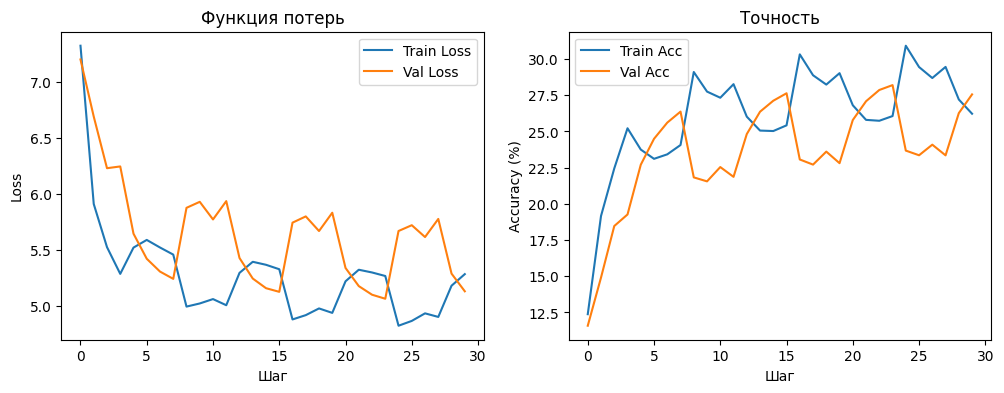

In [8]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Шаг")
plt.ylabel("Loss")
plt.legend()
plt.title("Функция потерь")

plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], label="Train Acc")
plt.plot(history["val_acc"], label="Val Acc")
plt.xlabel("Шаг")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.title("Точность")
plt.show()

In [24]:
def greedy_search(logits):
    return torch.argmax(logits, dim=-1, keepdim=True)


def random_sample(logits, temperature=1.0):
    if temperature <= 0:
        raise ValueError("Temperature должна быть больше 0")
    logits = logits / temperature
    probs = F.softmax(logits, dim=-1)
    return torch.multinomial(probs, num_samples=1)


def top_k_sample(logits, k=5, temperature=1.0):
    if temperature <= 0:
        raise ValueError("Temperature должна быть больше 0")
    if k <= 0:
        raise ValueError("k должна быть больше 0")
    k = min(k, logits.size(-1))
    logits = logits / temperature
    top_logits, top_indices = torch.topk(logits, k=k, dim=-1)
    probs = F.softmax(top_logits, dim=-1)
    choice_idx = torch.multinomial(probs, num_samples=1)
    return top_indices.gather(-1, choice_idx)


def top_p_sample(logits, p=0.9, temperature=1.0):
    if temperature <= 0:
        raise ValueError("Temperature должна быть больше 0")
    if not (0 < p <= 1):
        raise ValueError("p должна быть в диапазоне (0, 1]")
    logits = logits / temperature
    probs = F.softmax(logits, dim=-1)
    sorted_probs, sorted_indices = torch.sort(probs, descending=True, dim=-1)
    cumsum_probs = torch.cumsum(sorted_probs, dim=-1)
    mask = cumsum_probs <= p
    mask = torch.cat([torch.ones_like(mask[:, :1]), mask[:, :-1]], dim=-1)
    sorted_probs = sorted_probs * mask.float()
    sorted_probs = sorted_probs / sorted_probs.sum(dim=-1, keepdim=True)
    sampled_idx = torch.multinomial(sorted_probs, num_samples=1)
    return sorted_indices.gather(-1, sampled_idx)


def top_k_top_p_sample(logits, k=50, p=0.9, temperature=1.0):
    if temperature <= 0:
        raise ValueError("Temperature должна быть больше 0")
    if k <= 0:
        raise ValueError("k должна быть больше 0")
    if not (0 < p <= 1):
        raise ValueError("p должна быть в диапазоне (0, 1]")
    logits = logits / temperature
    top_k_logits, top_k_indices = torch.topk(logits, k=k, dim=-1)
    probs = F.softmax(top_k_logits, dim=-1)
    sorted_probs, sorted_indices = torch.sort(probs, descending=True, dim=-1)
    cumsum = torch.cumsum(sorted_probs, dim=-1)
    mask = cumsum <= p
    mask = torch.cat([torch.ones_like(mask[:, :1]), mask[:, :-1]], dim=-1)
    sorted_probs = sorted_probs * mask.float()
    sorted_probs = sorted_probs / sorted_probs.sum(dim=-1, keepdim=True)
    sampled_idx = torch.multinomial(sorted_probs, num_samples=1)
    final_idx = sorted_indices.gather(-1, sampled_idx)
    return top_k_indices.gather(-1, final_idx)


def generate_text(prompt, model, tokenizer, max_new_tokens=64,
                  sample_fn=greedy_search, device='cuda',
                  repetition_penalty=1.0):
    model.eval()
    input_ids = tokenizer.encode(prompt, add_special_tokens=False, return_tensors="pt").to(device)
    generated = input_ids.clone()

    with torch.no_grad():
        for _ in range(max_new_tokens):
            if generated.size(1) > SEQUENCE_LENGTH:
                context = generated[:, -SEQUENCE_LENGTH:]
            else:
                context = generated

            logits = model(context)
            next_logits = logits[:, -1, :]

            next_logits[:, PAD_ID] = -float("inf")
            if BOS_ID is not None:
                next_logits[:, BOS_ID] = -float("inf")

            if repetition_penalty != 1.0:
                for token_id in set(generated[0].tolist()):
                    next_logits[:, token_id] /= repetition_penalty

            next_token = sample_fn(next_logits)
            generated = torch.cat([generated, next_token], dim=1)

            if next_token.item() == EOS_ID:
                break

    output = tokenizer.decode(generated[0], skip_special_tokens=True)
    return output

In [25]:
checkpoint = torch.load("best_mini_gpt.pt", map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state"])
print("Модель загружена")

prompts = [
    "Рецепт очень простой",
    "Искусственный интеллект — это",
    "Привет, я",
    "Чтобы испечь блины, нужны:",
    "Основные шаги для создания сайта:",
    "Клиент: Здравствуйте, у меня проблема с заказом. Оператор:",
    "Город Москва — это",
    "Жил-был колобок, и однажды он",
    "Почему важно изучать программирование? Во-первых,",
]

for prompt in prompts:
    print(f"\n{'='*60}\nПромпт: {prompt}\n{'='*60}")

    gen = generate_text(prompt, model, tokenizer,
                        max_new_tokens=64,
                        sample_fn=greedy_search,
                        repetition_penalty=1.2)
    print(f"Жадный (repetition_penalty=1.2):\n{gen}\n")

    gen = generate_text(prompt, model, tokenizer,
                        max_new_tokens=64,
                        sample_fn=partial(random_sample, temperature=0.8),
                        repetition_penalty=1.0)
    print(f"Случайная (T=0.8):\n{gen}\n")

    gen = generate_text(prompt, model, tokenizer,
                        max_new_tokens=64,
                        sample_fn=partial(top_k_sample, k=5, temperature=0.7),
                        repetition_penalty=1.1)
    print(f"Top-k (k=5, T=0.7):\n{gen}\n")

    gen = generate_text(prompt, model, tokenizer,
                        max_new_tokens=64,
                        sample_fn=partial(top_p_sample, p=0.9, temperature=0.7),
                        repetition_penalty=1.1)
    print(f"Top-p (p=0.9, T=0.7):\n{gen}\n")

    gen = generate_text(prompt, model, tokenizer,
                        max_new_tokens=64,
                        sample_fn=partial(top_k_top_p_sample, k=50, p=0.9, temperature=0.7),
                        repetition_penalty=1.1)
    print(f"Top-k + Top-p (k=50, p=0.9, T=0.7):\n{gen}\n")

Модель загружена

Промпт: Рецепт очень простой
Жадный (repetition_penalty=1.2):
Рецепт очень простой, но не очень удобный.
- Не нужно использовать его для того, чтобы он был в качестве основы.
- Если вы хотите использовать этот метод, то лучше всего использовать его для того, чтобы он был в качестве основы.
- Если вы хотите использовать его для того, чтобы он был в качестве основы.


Случайная (T=0.8):
Рецепт очень простой, но оченьчный, поэтому думаю, что это так многое спасибо.
Я свойства воды были просто «порны», нужно было использовать также кусочек, где ничего нет. После этого к нам прилагается межи, в общем, всё отлично.
Есть ещё, что на меня вывода неred баллотировалось,

Top-k (k=5, T=0.7):
Рецепт очень простой и удобный для меня. В конце концов, я не могу сказать, что это очень важно.
- Как вы считаете, что это такое?
- Я могу сказать, что я не могу сказать что это очень просто.
- Как вы думаете, что такое такое такое?
- Я не могу сказать что такое

Top-p (p=0.9, T=0.7):
Рецеп

In [26]:
tokenizer.save_pretrained("./russian_tokenizer/")

checkpoint = torch.load("best_mini_gpt.pt", map_location=device, weights_only=False)
torch.save({
    "model_state": checkpoint["model_state"],
    "config": checkpoint["config"]
}, "mini_gpt_final.pt")

print("Модель и токенизатор сохранены.")

Модель и токенизатор сохранены.
